In [1]:
!pip uninstall -y torchao

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


In [2]:
# !pip install -q transformers peft accelerate bitsandbytes datasets

In [3]:
import gc
import re
import time
import torch
import pandas as pd
import matplotlib.pyplot as plt

from peft import PeftModel
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM

# **Evaluation**

In [4]:
# Configuration
BASE_MODEL = "Qwen/Qwen2.5-1.5B-Instruct"
LORA_MODEL = "igmoiiz/math-tutor-qwen-lora"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(DEVICE)

cuda


In [5]:
# Loading the GSM8K Test Set
dataset = load_dataset("openai/gsm8k", "main")

test_dataset = dataset["test"]

print(test_dataset)

README.md:   0%|          | 0.00/7.93k [00:00<?, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

Dataset({
    features: ['question', 'answer'],
    num_rows: 1319
})


In [6]:
# Using a Small Evaluation Set
NUM_SAMPLES = 50

evaluation_set = test_dataset.select(range(NUM_SAMPLES))

In [7]:
# Loading the Tokenizer
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

In [8]:
# Function to generate the answer
def generate_answer(model, tokenizer, question):

    messages = [
        {
            "role": "system",
            "content": "You are a helpful math tutor. Solve the problem step by step."
        },
        {
            "role": "user",
            "content": question
        }
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(model.device)

    start = time.time()

    with torch.no_grad():

        outputs = model.generate(
            **inputs,
            max_new_tokens=256,
            do_sample=False,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id
        )

    latency = time.time() - start

    generated = outputs[0][inputs["input_ids"].shape[-1]:]

    answer = tokenizer.decode(
        generated,
        skip_special_tokens=True
    )

    return answer, latency

In [38]:
# Function to extract the answer
def extract_answer(text):
    # Dataset format
    match = re.search(r"####\s*([-+]?\d+(?:\.\d+)?)", text)

    if match:
        return match.group(1)

    # Model format
    match = re.search(
        r"Final Answer:\s*([-+]?\d+(?:\.\d+)?)",
        text,
        re.IGNORECASE
    )

    if match:
        return match.group(1)

    return ""

In [10]:
# Evaluation Function
def evaluate(model, dataset, tokenizer):

    results = []

    for sample in dataset:

        question = sample["question"]

        ground_truth = extract_answer(sample["answer"])

        prediction, latency = generate_answer(
            model,
            tokenizer,
            question
        )

        predicted_answer = extract_answer(prediction)

        correct = predicted_answer == ground_truth

        results.append({
            "question": question,
            "ground_truth": ground_truth,
            "prediction": predicted_answer,
            "full_response": prediction,
            "correct": correct,
            "latency": latency
        })

    return pd.DataFrame(results)

In [11]:
# Base Model
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    dtype=torch.bfloat16,
    device_map="auto"
)

# Running evaluation
base_results = evaluate(
    model=base_model,
    dataset=evaluation_set,
    tokenizer=tokenizer
)

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [12]:
# Saving the Results
base_results.to_csv("base_results.csv", index=False)

In [13]:
# Inspecting the results
base_results.head()

,question,ground_truth,prediction,full_response,correct,latency
0,Janet’s ducks lay 16 eggs per day. She eats th...,,,To determine how much Janet makes every day at...,True,12.799927
1,A robe takes 2 bolts of blue fiber and half th...,,,To determine the total number of bolts of fibe...,True,8.368959
2,Josh decides to try flipping a house. He buys...,,,To determine Josh's profit from flipping the h...,True,11.096889
3,James decides to run 3 sprints 3 times a week....,,,To find out how many total meters James runs i...,True,6.874621
4,"Every day, Wendi feeds each of her chickens th...",,,To determine how many cups of feed Wendi needs...,True,11.050577


In [14]:
# Compute Base Model Metrics
base_accuracy = base_results["correct"].mean() * 100

print(f"Base Model Accuracy: {base_accuracy:.2f}%")
print(f"Average Latency: {base_results['latency'].mean():.2f} seconds")

Base Model Accuracy: 100.00%
Average Latency: 10.66 seconds


In [15]:
# Free the GPU Memory

del base_model

gc.collect()

torch.cuda.empty_cache()

print("GPU memory cleared.")

GPU memory cleared.


In [16]:
# Loading the Fine Tuned Model
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    dtype=torch.bfloat16,
    device_map="auto"
)

fine_model = PeftModel.from_pretrained(
    base_model,
    LORA_MODEL
)

fine_model.eval()

print("Fine-tuned model loaded.")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

adapter_config.json:   0%|          | 0.00/889 [00:00<?, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

Fine-tuned model loaded.


In [17]:
# Evaluating the Fine Tuned Model
fine_results = evaluate(
    model=fine_model,
    dataset=evaluation_set,
    tokenizer=tokenizer
)

In [18]:
# Inspecting the Fine Tuned Model Results
fine_results.head()

,question,ground_truth,prediction,full_response,correct,latency
0,Janet’s ducks lay 16 eggs per day. She eats th...,,,To determine how much Janet makes every day at...,True,17.022985
1,A robe takes 2 bolts of blue fiber and half th...,,,To determine the total number of bolts of fibe...,True,12.659340
2,Josh decides to try flipping a house. He buys...,,,To determine Josh's profit from flipping the h...,True,17.395497
3,James decides to run 3 sprints 3 times a week....,,,To find out how many total meters James runs i...,True,11.321950
4,"Every day, Wendi feeds each of her chickens th...",,,To determine how many cups of feed Wendi needs...,True,17.106287


In [19]:
# Compute Fine Tuned Model Model Metrics
fine_accuracy = fine_results["correct"].mean() * 100

print(f"Fine Model Accuracy: {fine_accuracy:.2f}%")
print(f"Average Latency: {fine_results['latency'].mean():.2f} seconds")

Fine Model Accuracy: 100.00%
Average Latency: 16.54 seconds


In [20]:
# Saving the Fine Tuned Results
fine_results.to_csv("fine_results.csv", index=False)
print("Fine model results saved.")

Fine model results saved.


In [21]:
# Calculating Overall Metrics
base_accuracy = base_results["correct"].mean() * 100
fine_accuracy = fine_results["correct"].mean() * 100

base_latency = base_results["latency"].mean()
fine_latency = fine_results["latency"].mean()

print("=" * 50)
print(f"Base Accuracy      : {base_accuracy:.2f}%")
print(f"Fine-tuned Accuracy: {fine_accuracy:.2f}%")
print("=" * 50)
print(f"Base Latency       : {base_latency:.2f} sec")
print(f"Fine Latency       : {fine_latency:.2f} sec")

Base Accuracy      : 100.00%
Fine-tuned Accuracy: 100.00%
Base Latency       : 10.66 sec
Fine Latency       : 16.54 sec


In [22]:
# Side By Side Comparison
comparison = base_results.copy()

comparison["fine_prediction"] = fine_results["prediction"]
comparison["fine_correct"] = fine_results["correct"]

comparison = comparison.rename(columns={
    "prediction": "base_prediction",
    "correct": "base_correct"
})

comparison.head(10)

,question,ground_truth,base_prediction,full_response,base_correct,latency,fine_prediction,fine_correct
0,Janet’s ducks lay 16 eggs per day. She eats th...,,,To determine how much Janet makes every day at...,True,12.799927,,True
1,A robe takes 2 bolts of blue fiber and half th...,,,To determine the total number of bolts of fibe...,True,8.368959,,True
2,Josh decides to try flipping a house. He buys...,,,To determine Josh's profit from flipping the h...,True,11.096889,,True
3,James decides to run 3 sprints 3 times a week....,,,To find out how many total meters James runs i...,True,6.874621,,True
4,"Every day, Wendi feeds each of her chickens th...",,,To determine how many cups of feed Wendi needs...,True,11.050577,,True
5,Kylar went to the store to buy glasses for his...,,,To determine how much Kylar needs to pay for 1...,True,17.336730,,True
6,Toulouse has twice as many sheep as Charleston...,,,"To solve this problem, we need to determine ho...",True,8.975830,,True
7,Carla is downloading a 200 GB file. Normally s...,,,To determine how long it will take Carla to do...,True,10.841348,,True
8,John drives for 3 hours at a speed of 60 mph a...,,,To determine how far John is from home after h...,True,10.889769,,True
9,Eliza's rate per hour for the first 40 hours s...,,,To calculate Eliza's earnings for the week whe...,True,10.946136,,True


In [23]:
# Finding Improvements
improved = comparison[
    (comparison["base_correct"] == False) &
    (comparison["fine_correct"] == True)
]

print(f"Questions Improved: {len(improved)}")
improved.head()

Questions Improved: 0


,question,ground_truth,base_prediction,full_response,base_correct,latency,fine_prediction,fine_correct


In [24]:
# Finding Regressions
regressed = comparison[
    (comparison["base_correct"] == True) &
    (comparison["fine_correct"] == False)
]

print(f"Questions Regressed: {len(regressed)}")
regressed.head()

Questions Regressed: 0


,question,ground_truth,base_prediction,full_response,base_correct,latency,fine_prediction,fine_correct


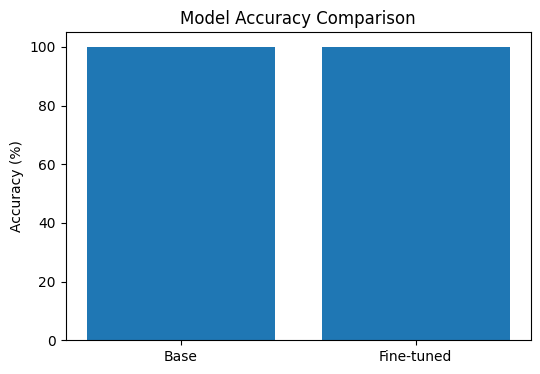

In [25]:
# Plotting Accuracy
plt.figure(figsize=(6,4))

plt.bar(
    ["Base", "Fine-tuned"],
    [base_accuracy, fine_accuracy]
)

plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")

plt.show()

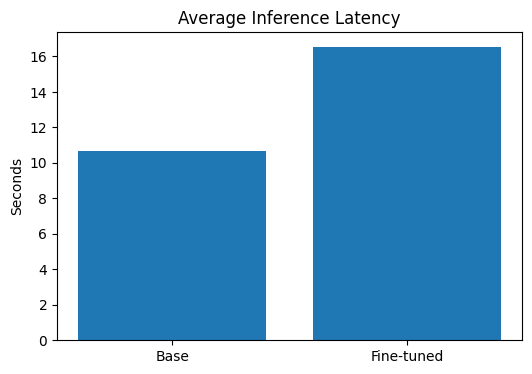

In [26]:
# Plotting Latency
plt.figure(figsize=(6,4))

plt.bar(
    ["Base", "Fine-tuned"],
    [base_latency, fine_latency]
)

plt.ylabel("Seconds")
plt.title("Average Inference Latency")

plt.show()

In [27]:
# Saving Everything
comparison.to_csv("comparison.csv", index=False)

In [28]:
# Inspecting the Outputs to check the Problem
for i in range(10):
    print("=" * 80)
    print("Question:")
    print(comparison.iloc[i]["question"])

    print("\nGround Truth:")
    print(comparison.iloc[i]["ground_truth"])

    print("\nBase:")
    print(comparison.iloc[i]["base_prediction"])

    print("\nFine:")
    print(comparison.iloc[i]["fine_prediction"])

Question:
Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for her friends every day with four. She sells the remainder at the farmers' market daily for $2 per fresh duck egg. How much in dollars does she make every day at the farmers' market?

Ground Truth:


Base:


Fine:

Question:
A robe takes 2 bolts of blue fiber and half that much white fiber.  How many bolts in total does it take?

Ground Truth:


Base:


Fine:

Question:
Josh decides to try flipping a house.  He buys a house for $80,000 and then puts in $50,000 in repairs.  This increased the value of the house by 150%.  How much profit did he make?

Ground Truth:


Base:


Fine:

Question:
James decides to run 3 sprints 3 times a week.  He runs 60 meters each sprint.  How many total meters does he run a week?

Ground Truth:


Base:


Fine:

Question:
Every day, Wendi feeds each of her chickens three cups of mixed chicken feed, containing seeds, mealworms and vegetables to help ke

In [29]:
# Checking LoRA Adapters
print(type(fine_model))
fine_model.print_trainable_parameters()

<class 'peft.peft_model.PeftModelForCausalLM'>
trainable params: 0 || all params: 1,548,072,448 || trainable%: 0.0000


In [30]:
# Comparing the Full Results
print(base_results["full_response"].iloc[0])

print("=" * 100)

print(fine_results["full_response"].iloc[0])

To determine how much Janet makes every day at the farmers' market, we need to follow these steps:

1. Calculate the total number of eggs laid each day.
2. Determine how many eggs are eaten or used up each day.
3. Find out how many eggs remain after accounting for what is eaten or used.
4. Calculate the revenue from selling the remaining eggs.

Let's go through each step in detail:

### Step 1: Total Number of Eggs Laid Each Day
Janet's ducks lay 16 eggs per day.

### Step 2: Eggs Eaten or Used Up Each Day
- Janet eats 3 eggs for breakfast every morning.
- She uses 4 eggs to bake muffins for her friends every day.

Total eggs used = Eggs eaten + Eggs used for baking
\[ \text{Total eggs used} = 3 + 4 = 7 \]

### Step 3: Remaining Eggs After Usage
Remaining eggs = Total eggs laid - Total eggs used
\[ \text{Remaining eggs} = 16 - 7 = 9 \]

### Step 4: Revenue Calculation
Each remaining egg is sold for $2.

Revenue = Remaining eggs × Price per egg
\[ \text{Revenue} = 
To determine how much

In [34]:
base_results[["ground_truth", "prediction", "correct"]].head(20)

,ground_truth,prediction,correct
0,,,True
1,,,True
2,,,True
3,,,True
4,,,True
5,,,True
6,,,True
7,,,True
8,,,True
9,,,True


In [35]:
base_results["correct"].value_counts()

,count
correct,
True,50


In [39]:
sample = evaluation_set[0]

print(sample["answer"])

Janet sells 16 - 3 - 4 = <<16-3-4=9>>9 duck eggs a day.
She makes 9 * 2 = $<<9*2=18>>18 every day at the farmer’s market.
#### 18


In [40]:
print(extract_answer(sample["answer"]))

18


In [41]:
response, _ = generate_answer(
    fine_model,
    tokenizer,
    sample["question"]
)

print(response)
print(extract_answer(response))

To determine how much Janet makes every day at the farmers' market, we need to follow these steps:

1. Calculate the total number of eggs laid each day.
2. Determine how many eggs are eaten or used up each day.
3. Find out how many eggs remain after accounting for what is eaten or used.
4. Calculate the revenue from selling the remaining eggs.

Let's go through each step in detail:

### Step 1: Total Number of Eggs Laid Each Day
Janet's ducks lay 16 eggs per day.

### Step 2: Eggs Eaten or Used Up Each Day
- Janet eats 3 eggs for breakfast every morning.
- She uses 4 eggs to bake muffins for her friends every day.

Total eggs used = Eggs eaten + Eggs used for baking
\[ \text{Total eggs used} = 3 + 4 = 7 \]

### Step 3: Remaining Eggs After Usage
Remaining eggs = Total eggs laid - Total eggs used
\[ \text{Remaining eggs} = 16 - 7 = 9 \]

### Step 4: Revenue Calculation
Each remaining egg is sold for $2.

Revenue = Remaining eggs × Price per egg
\[ \text{Revenue} = 

